In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path('../data/processed')
schools = pd.read_csv(PROCESSED / 'schools.csv')
districts = pd.read_csv(PROCESSED / 'districts.csv')
statewide = pd.read_csv(PROCESSED / 'statewide.csv')

# Light plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"Schools:   {len(schools):,} rows, {schools['school_id'].nunique()} unique schools, cohorts {schools['cohort_year'].min()}–{schools['cohort_year'].max()}")
print(f"Districts: {len(districts):,} rows, {districts['lea_id'].nunique()} unique LEAs")
print(f"Statewide: {len(statewide):,} rows")

Schools:   9,053 rows, 829 unique schools, cohorts 2010–2025
Districts: 5,147 rows, 419 unique LEAs
Statewide: 16 rows


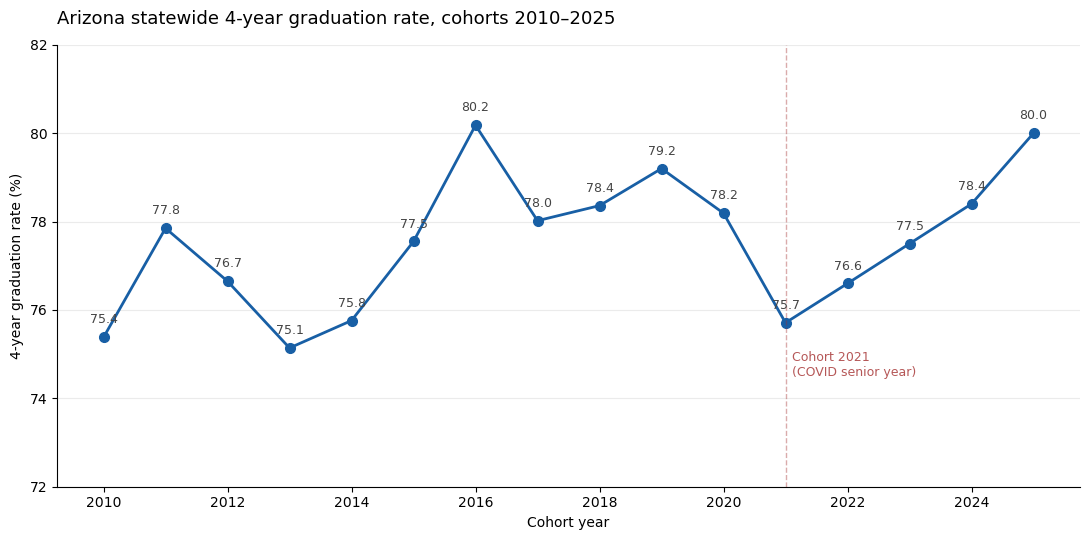


Key numbers:
  Lowest rate:  75.1% (Cohort 2013)
  Highest rate: 80.2% (Cohort 2016)
  COVID drop:   78.2% → 75.7% (-2.5pp)
  Recovery:     75.7% → 80.0% (+4.3pp over 4 cohorts)


In [2]:
fig, ax = plt.subplots(figsize=(11, 5.5))

s = statewide.sort_values('cohort_year')
ax.plot(s['cohort_year'], s['grad_rate'], marker='o', linewidth=2, color='#185FA5', markersize=7)

# Annotate each point with its value
for _, row in s.iterrows():
    ax.annotate(f"{row['grad_rate']:.1f}", 
                (row['cohort_year'], row['grad_rate']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9, color='#444')

# Mark the COVID cohort
ax.axvline(x=2021, color='#A32D2D', linestyle='--', alpha=0.4, linewidth=1)
ax.text(2021.1, 74.5, 'Cohort 2021\n(COVID senior year)', fontsize=9, color='#A32D2D', alpha=0.8)

ax.set_xlabel('Cohort year')
ax.set_ylabel('4-year graduation rate (%)')
ax.set_title('Arizona statewide 4-year graduation rate, cohorts 2010–2025', 
             fontsize=13, pad=15, loc='left')
ax.set_ylim(72, 82)
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('../analysis/fig01-statewide-trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey numbers:")
print(f"  Lowest rate:  {s['grad_rate'].min():.1f}% (Cohort {s.loc[s['grad_rate'].idxmin(), 'cohort_year']})")
print(f"  Highest rate: {s['grad_rate'].max():.1f}% (Cohort {s.loc[s['grad_rate'].idxmax(), 'cohort_year']})")
print(f"  COVID drop:   {s.loc[s['cohort_year']==2020, 'grad_rate'].values[0]:.1f}% → {s.loc[s['cohort_year']==2021, 'grad_rate'].values[0]:.1f}% ({s.loc[s['cohort_year']==2021, 'grad_rate'].values[0] - s.loc[s['cohort_year']==2020, 'grad_rate'].values[0]:.1f}pp)")
print(f"  Recovery:     {s.loc[s['cohort_year']==2021, 'grad_rate'].values[0]:.1f}% → {s.loc[s['cohort_year']==2025, 'grad_rate'].values[0]:.1f}% (+{s.loc[s['cohort_year']==2025, 'grad_rate'].values[0] - s.loc[s['cohort_year']==2021, 'grad_rate'].values[0]:.1f}pp over 4 cohorts)")

In [3]:
# Compare each school's grad rate in Cohort 2025 vs Cohort 2020 (5 years apart)
# Using 2020 as the "pre-COVID" reference point rather than 2021

def get_year(df, year, level_id_col):
    """Extract one year's data, keyed by school or LEA id."""
    return df[df['cohort_year'] == year].set_index(level_id_col)

schools_2020 = get_year(schools, 2020, 'school_id')
schools_2025 = get_year(schools, 2025, 'school_id')

# Join on school_id, keep schools that appear in both years with usable grad rates
movers = schools_2020[['school_name', 'lea_name', 'county', 'grad_rate', 'n_cohort']].join(
    schools_2025[['grad_rate', 'n_cohort']], 
    lsuffix='_2020', rsuffix='_2025', how='inner'
)

# Require both years to have actual rates (not suppressed) AND a meaningful cohort size
movers = movers.dropna(subset=['grad_rate_2020', 'grad_rate_2025'])
movers = movers[(movers['n_cohort_2020'] >= 30) & (movers['n_cohort_2025'] >= 30)]

movers['change_pp'] = movers['grad_rate_2025'] - movers['grad_rate_2020']

print(f"Schools with comparable data in both Cohort 2020 and 2025 (cohort size ≥ 30): {len(movers)}\n")

print("="*90)
print("TOP 15 IMPROVERS (biggest gains from Cohort 2020 → 2025)")
print("="*90)
top_gainers = movers.nlargest(15, 'change_pp')[['school_name', 'lea_name', 'county', 'grad_rate_2020', 'grad_rate_2025', 'change_pp', 'n_cohort_2025']]
print(top_gainers.to_string())

print("\n" + "="*90)
print("BOTTOM 15 (biggest drops from Cohort 2020 → 2025)")
print("="*90)
top_droppers = movers.nsmallest(15, 'change_pp')[['school_name', 'lea_name', 'county', 'grad_rate_2020', 'grad_rate_2025', 'change_pp', 'n_cohort_2025']]
print(top_droppers.to_string())

Schools with comparable data in both Cohort 2020 and 2025 (cohort size ≥ 30): 228

TOP 15 IMPROVERS (biggest gains from Cohort 2020 → 2025)
                                                     school_name                                                       lea_name    county  grad_rate_2020  grad_rate_2025  change_pp  n_cohort_2025
school_id                                                                                                                                                                                          
92044                               Southwest Leadership Academy                                   Southwest Leadership Academy  Maricopa           26.04            74.5      48.46           51.0
875776                                       PXU Digital Academy                             Phoenix Union High School District  Maricopa           14.29            60.6      46.31           99.0
79702                                Arizona Preparatory Academy            

In [5]:
import json

SITE_DIR = Path('../site')
SITE_DIR.mkdir(exist_ok=True)

MIN_COHORT_FOR_DISPLAY = 20  # drop rate values when the cohort was this small

# Only districts active in the most recent 5 years (cohorts 2021–2025)
recent_years = {2021, 2022, 2023, 2024, 2025}
recent_active_ids = set(
    districts[districts['cohort_year'].isin(recent_years)]['lea_id'].unique()
)
print(f"Districts active 2021–2025: {len(recent_active_ids)}")

district_series = []
dropped_small_cohort = 0

for lea_id, g in districts[districts['lea_id'].isin(recent_active_ids)].groupby('lea_id'):
    # Use the most recent LEA name + county (names can change over time)
    g_sorted = g.sort_values('cohort_year')
    latest = g_sorted.iloc[-1]
    latest_name = latest['lea_name']
    latest_county = latest['county'] if pd.notna(latest['county']) else None
    
    rates = {}
    cohorts = {}
    for _, row in g.iterrows():
        if pd.isna(row['grad_rate']) or pd.isna(row['n_cohort']):
            continue
        if int(row['n_cohort']) < MIN_COHORT_FOR_DISPLAY:
            dropped_small_cohort += 1
            continue
        rates[int(row['cohort_year'])] = round(float(row['grad_rate']), 1)
        cohorts[int(row['cohort_year'])] = int(row['n_cohort'])
    
    if rates:
        district_series.append({
            'id': int(lea_id),
            'name': latest_name,
            'county': latest_county,
            'rates': rates,
            'cohorts': cohorts,
        })

district_series.sort(key=lambda d: d['name'])

statewide_series = {
    'rates': {int(r['cohort_year']): round(float(r['grad_rate']), 1) 
              for _, r in statewide.iterrows()},
    'cohorts': {int(r['cohort_year']): int(r['n_cohort']) 
                for _, r in statewide.iterrows()},
}

output = {
    'years': sorted(statewide['cohort_year'].unique().tolist()),
    'statewide': statewide_series,
    'districts': district_series,
    'min_cohort_for_display': MIN_COHORT_FOR_DISPLAY,
    'generated_from': 'data/processed/{districts,statewide}.csv',
}

with open(SITE_DIR / 'data.json', 'w') as f:
    json.dump(output, f, separators=(',', ':'))

import os
print(f"Wrote {SITE_DIR / 'data.json'} ({os.path.getsize(SITE_DIR / 'data.json')/1024:.1f} KB)")
print(f"Districts included: {len(district_series)}")
print(f"Dropped {dropped_small_cohort} data points with cohort < {MIN_COHORT_FOR_DISPLAY}")

# Check duplicates — which district names appear more than once?
from collections import Counter
name_counts = Counter(d['name'] for d in district_series)
dupes = {name: count for name, count in name_counts.items() if count > 1}
print(f"\nDistricts with duplicate names ({len(dupes)}):")
for name, count in sorted(dupes.items()):
    print(f"  {name}: {count} entities")

Districts active 2021–2025: 341
Wrote ../site/data.json (104.1 KB)
Districts included: 299
Dropped 216 data points with cohort < 20

Districts with duplicate names (4):
  ASU Preparatory Academy: 3 entities
  Arizona Agribusiness & Equine Center, Inc.: 5 entities
  BASIS Charter Schools, Inc.: 10 entities
  Portable Practical Educational Preparation, Inc. (PPEP, Inc.): 2 entities


In [6]:
# Find all district-year combos with weirdly low rates (potential data quality issues)
low_outliers = districts[
    (districts['grad_rate'].notna()) &
    (districts['grad_rate'] < 20) &
    (districts['n_cohort'] >= 20)  # not suppressed, not tiny
].sort_values(['cohort_year', 'grad_rate'])

print(f"{len(low_outliers)} district-year combos with grad_rate < 20% and cohort ≥ 20:")
print(low_outliers[['cohort_year', 'lea_id', 'lea_name', 'grad_rate', 'n_cohort']].to_string())

273 district-year combos with grad_rate < 20% and cohort ≥ 20:
      cohort_year   lea_id                                                                          lea_name  grad_rate  n_cohort
1776         2010     4234                                                 Maricopa County Regional District   0.000000     162.0
1780         2010    79499                                                       Masada Charter School, Inc.   0.000000      21.0
1822         2010     4401                                                       Pima Accommodation District   0.000000     244.0
1860         2010    85848                                        Santa Cruz County Regional School District   0.000000      20.0
1633         2010    87407                                  Arizona Connections Academy Charter School, Inc.   2.200000      46.0
1805         2010     4323  Ombudsman Educational Services, Ltd.,a subsidiary of Educational Services of Ame   2.800000     145.0
1710         2010    87336 

In [7]:
# Classify districts by naming convention, then check each bucket for obvious misclassifications
import re

def classify_lea(name):
    if pd.isna(name):
        return 'unknown'
    n = name.lower()
    # Traditional district patterns
    if re.search(r'\bunified\b', n): return 'traditional'
    if re.search(r'\belementary district\b|\belementary school district\b', n): return 'traditional'
    if re.search(r'\bhigh school district\b', n): return 'traditional'
    if re.search(r'\bcommon school district\b', n): return 'traditional'
    if re.search(r'\bjoint (unified|elementary|high school|common) district\b', n): return 'traditional'
    # County accommodation districts — run detention/juvie schools
    if 'accommodation' in n or 'regional district' in n or 'regional school district' in n:
        return 'accommodation'
    # JTED (Joint Technical Education Districts) — career/tech, grades 9-12 usually
    if re.search(r'\bjted\b|joint technical education|technological education', n):
        return 'jted'
    # Almost everything else is a charter holder corporation
    if re.search(r',?\s*(inc\.?|l\.?l\.?c\.?|ltd\.?)$', n.strip(), re.IGNORECASE):
        return 'charter_corp'
    if 'charter' in n or 'academy' in n:
        return 'charter_corp'
    if 'foundation' in n or 'corporation' in n or 'schools, inc' in n:
        return 'charter_corp'
    if 'dba' in n or 'd.b.a' in n or 'd/b/a' in n:
        return 'charter_corp'
    return 'other'

# Apply to unique LEAs (most recent name)
latest_names = (
    districts.sort_values('cohort_year')
             .drop_duplicates('lea_id', keep='last')
             [['lea_id', 'lea_name', 'county']]
             .copy()
)
latest_names['lea_type'] = latest_names['lea_name'].apply(classify_lea)

print("Count by lea_type:")
print(latest_names['lea_type'].value_counts().to_string())

# For each bucket, show 10 random examples so you can eyeball
import numpy as np
np.random.seed(42)
for lea_type in latest_names['lea_type'].unique():
    subset = latest_names[latest_names['lea_type'] == lea_type]
    sample = subset.sample(min(15, len(subset)))
    print(f"\n--- {lea_type} ({len(subset)} total) — sample of {len(sample)} ---")
    for _, row in sample.iterrows():
        print(f"  {row['lea_name']}")

Count by lea_type:
charter_corp     231
traditional      115
other             63
accommodation      9
jted               1

--- other (63 total) — sample of 15 ---
  Presidio School
  Phoenix School of Academic Excellence The
  Phoenix Education Management, LLC,
  Career Success Schools
  Edkey, Inc. - Sequoia Ranch School
  Desert Sage School
  SySTEM Schools
  The Shelby School
  Legacy Education Group
  Portable Practical Educational Preparation, Inc. (PPEP, Inc.)
  Utah High School
  Ombudsman Educational Services, LTD, a subsidiary of Educational Services of Ame
  Pima Prevention Partnership
  Westwind Children's Services
  Madison Highland Prep

--- charter_corp (231 total) — sample of 15 ---
  E.A.G.L.E. Academy, Inc.
  Sierra Summit Academy
  American Charter Schools Foundation dba Ridgeview College Preparatory High School
  Heritage Academy, Inc.
  American Charter Schools Foundation d.b.a. South Pointe High School
  Daisy Education Corporation dba Sonoran Science Academy
  L

In [8]:
import json

SITE_DIR = Path('../site')
SITE_DIR.mkdir(exist_ok=True)
MIN_COHORT_FOR_DISPLAY = 20

# Load the authoritative traditional district list
trad = pd.read_csv('../data/reference/traditional_districts.csv')
trad_by_id = {int(r['lea_id']): r for _, r in trad.iterrows()}
trad_ids = set(trad_by_id.keys())

# Districts must be (a) on the traditional list AND (b) active in recent 5 years
recent_years = {2021, 2022, 2023, 2024, 2025}
recent_active_ids = set(
    districts[districts['cohort_year'].isin(recent_years)]['lea_id'].unique()
)
included_ids = trad_ids & recent_active_ids

print(f"Traditional districts from NCES:   {len(trad_ids)}")
print(f"Active in grad data 2021–2025:     {len(recent_active_ids)}")
print(f"Intersection (in the tool):        {len(included_ids)}")

district_series = []
dropped_small_cohort = 0

for lea_id, g in districts[districts['lea_id'].isin(included_ids)].groupby('lea_id'):
    # Prefer NCES name — it's canonical. Fall back to grad data if missing.
    nces_info = trad_by_id.get(int(lea_id))
    name = nces_info['district_name'] if nces_info is not None else g.sort_values('cohort_year').iloc[-1]['lea_name']
    county = nces_info['county'].replace(' County', '') if nces_info is not None else None
    city = nces_info['city'] if nces_info is not None else None
    
    rates = {}
    cohorts = {}
    for _, row in g.iterrows():
        if pd.isna(row['grad_rate']) or pd.isna(row['n_cohort']):
            continue
        if int(row['n_cohort']) < MIN_COHORT_FOR_DISPLAY:
            dropped_small_cohort += 1
            continue
        rates[int(row['cohort_year'])] = round(float(row['grad_rate']), 1)
        cohorts[int(row['cohort_year'])] = int(row['n_cohort'])
    
    if rates:
        district_series.append({
            'id': int(lea_id),
            'name': name,
            'county': county,
            'city': city,
            'rates': rates,
            'cohorts': cohorts,
        })

district_series.sort(key=lambda d: d['name'])

statewide_series = {
    'rates': {int(r['cohort_year']): round(float(r['grad_rate']), 1) 
              for _, r in statewide.iterrows()},
    'cohorts': {int(r['cohort_year']): int(r['n_cohort']) 
                for _, r in statewide.iterrows()},
}

output = {
    'years': sorted(statewide['cohort_year'].unique().tolist()),
    'statewide': statewide_series,
    'districts': district_series,
    'min_cohort_for_display': MIN_COHORT_FOR_DISPLAY,
    'generated_from': 'data/processed/{districts,statewide}.csv + data/reference/traditional_districts.csv',
}

with open(SITE_DIR / 'data.json', 'w') as f:
    json.dump(output, f, separators=(',', ':'))

import os
print(f"\nWrote {SITE_DIR / 'data.json'} ({os.path.getsize(SITE_DIR / 'data.json')/1024:.1f} KB)")
print(f"Districts in tool:   {len(district_series)}")
print(f"Dropped {dropped_small_cohort} data points with cohort < {MIN_COHORT_FOR_DISPLAY}")

# Duplicate name check
from collections import Counter
name_counts = Counter(d['name'] for d in district_series)
dupes = {n: c for n, c in name_counts.items() if c > 1}
print(f"\nDuplicate names: {len(dupes)}")
for n, c in sorted(dupes.items()):
    print(f"  {n}: {c}")

Traditional districts from NCES:   214
Active in grad data 2021–2025:     341
Intersection (in the tool):        114

Wrote ../site/data.json (46.4 KB)
Districts in tool:   107
Dropped 34 data points with cohort < 20

Duplicate names: 0
